# 📘 Module 5.1 — Tokenization & Embeddings

**Goal:** Understand how text is converted to numbers for neural networks.

## Why Tokenization for ADAS?
- 🗣️ **Voice commands:** "Take the next exit" → tokens → model
- 📝 **Scene description:** LLMs describe driving scenarios in text
- 🔗 **Multimodal models (VLMs):** Combine image tokens + text tokens
- 📋 **Log analysis:** Process driving logs and incident reports

---

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

## 1. Tokenization Methods

| Method | Example | Vocabulary Size |
|--------|---------|----------------|
| **Character** | `d, r, i, v, e` | ~100 |
| **Word** | `drive, car, lane` | ~100,000+ |
| **Subword (BPE)** | `driv, ##ing` | ~30,000-50,000 |
| **SentencePiece** | `▁drive, ▁car` | ~32,000 |

In [2]:
# --- Simple Word Tokenization ---
text = "The autonomous car detected a pedestrian crossing the road"

# Simple word tokenizer
words = text.lower().split()
vocab = {word: idx for idx, word in enumerate(sorted(set(words)))}
vocab['<PAD>'] = len(vocab)
vocab['<UNK>'] = len(vocab)

tokens = [vocab.get(w, vocab['<UNK>']) for w in words]

print(f"Text: '{text}'")
print(f"Words: {words}")
print(f"Vocabulary: {vocab}")
print(f"Token IDs: {tokens}")

Text: 'The autonomous car detected a pedestrian crossing the road'
Words: ['the', 'autonomous', 'car', 'detected', 'a', 'pedestrian', 'crossing', 'the', 'road']
Vocabulary: {'a': 0, 'autonomous': 1, 'car': 2, 'crossing': 3, 'detected': 4, 'pedestrian': 5, 'road': 6, 'the': 7, '<PAD>': 8, '<UNK>': 9}
Token IDs: [7, 1, 2, 4, 0, 5, 3, 7, 6]


In [3]:
# --- BPE Tokenization (used by GPT, LLaMA) ---
# Byte-Pair Encoding builds vocabulary from character pairs

# Simple BPE-like demonstration
def simple_bpe_demo(word, num_merges=5):
    """Demonstrate BPE concept."""
    chars = list(word) + ['</w>']  # End-of-word marker
    print(f"Initial: {chars}")
    
    tokens = chars[:]
    for i in range(min(num_merges, len(tokens)-1)):
        # Find most common pair (simplified: just merge adjacent)
        if i < len(tokens) - 1:
            merged = tokens[i] + tokens[i+1]
            tokens = tokens[:i] + [merged] + tokens[i+2:]
            print(f"Merge {i+1}: {tokens}")
    
    return tokens

print("BPE tokenization of 'autonomous':")
result = simple_bpe_demo('autonomous', 4)
print(f"\nFinal tokens: {result}")
print("\n💡 Real BPE learns merges from corpus statistics")

BPE tokenization of 'autonomous':
Initial: ['a', 'u', 't', 'o', 'n', 'o', 'm', 'o', 'u', 's', '</w>']
Merge 1: ['au', 't', 'o', 'n', 'o', 'm', 'o', 'u', 's', '</w>']
Merge 2: ['au', 'to', 'n', 'o', 'm', 'o', 'u', 's', '</w>']
Merge 3: ['au', 'to', 'no', 'm', 'o', 'u', 's', '</w>']
Merge 4: ['au', 'to', 'no', 'mo', 'u', 's', '</w>']

Final tokens: ['au', 'to', 'no', 'mo', 'u', 's', '</w>']

💡 Real BPE learns merges from corpus statistics


In [4]:
# --- Using Hugging Face Tokenizer ---
# Uncomment to use (requires: pip install transformers)

# from transformers import AutoTokenizer
# 
# tokenizer = AutoTokenizer.from_pretrained('gpt2')
# 
# text = "The autonomous vehicle detected a pedestrian at the crosswalk."
# encoded = tokenizer(text, return_tensors='pt')
# 
# print(f"Text: {text}")
# print(f"Token IDs: {encoded['input_ids']}")
# print(f"Tokens: {tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])}")
# print(f"Vocabulary size: {tokenizer.vocab_size}")

# Simulated output for demonstration
print("GPT-2 Tokenizer Example:")
print("Text: 'The autonomous vehicle detected a pedestrian at the crosswalk.'")
print("Tokens: ['The', ' autonomous', ' vehicle', ' detected', ' a', ' pedestrian', ' at', ' the', ' cross', 'walk', '.']")
print("Notice: 'crosswalk' → ['cross', 'walk'] (subword tokenization!)")

GPT-2 Tokenizer Example:
Text: 'The autonomous vehicle detected a pedestrian at the crosswalk.'
Tokens: ['The', ' autonomous', ' vehicle', ' detected', ' a', ' pedestrian', ' at', ' the', ' cross', 'walk', '.']
Notice: 'crosswalk' → ['cross', 'walk'] (subword tokenization!)


## 2. Word Embeddings

Embeddings map discrete tokens to continuous vectors where **semantic similarity = vector proximity**.

```
Token ID: 42 → Lookup Table → [0.12, -0.55, 0.78, ..., 0.33]  (d_model dimensions)
```

In [5]:
# --- Embedding Layer ---
vocab_size = 50000   # Size of vocabulary
embed_dim = 256      # Embedding dimension

embedding = nn.Embedding(vocab_size, embed_dim)

# Convert token IDs to embeddings
token_ids = torch.tensor([[42, 156, 7823, 1, 0]])  # batch of 1, 5 tokens
embedded = embedding(token_ids)

print(f"Token IDs: {token_ids.shape}")
print(f"Embeddings: {embedded.shape}")
print(f"\nEach token ID is mapped to a {embed_dim}-dimensional vector")
print(f"Embedding table size: {vocab_size} × {embed_dim} = {vocab_size * embed_dim:,} parameters")

Token IDs: torch.Size([1, 5])
Embeddings: torch.Size([1, 5, 256])

Each token ID is mapped to a 256-dimensional vector
Embedding table size: 50000 × 256 = 12,800,000 parameters


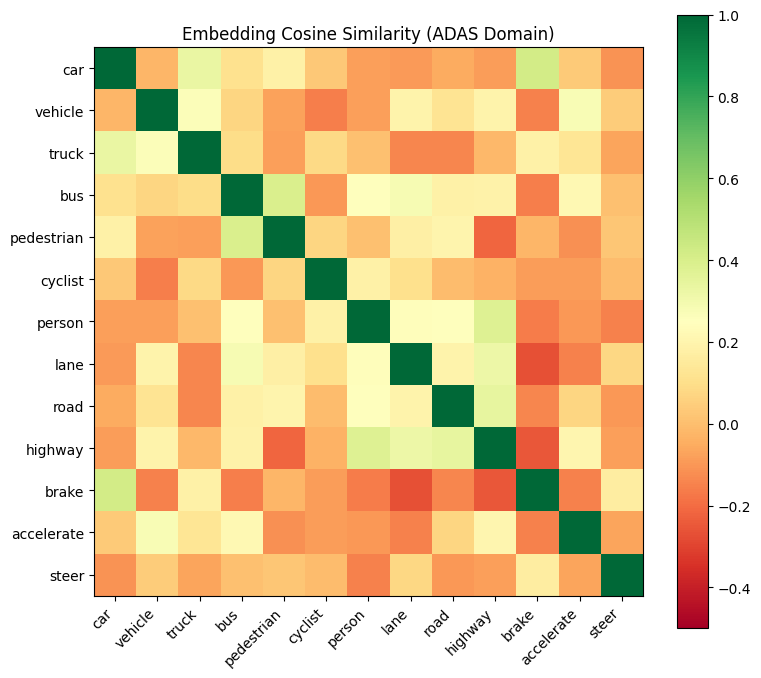

In [6]:
# --- Visualize Embedding Similarity ---
# In trained embeddings, similar words are close in vector space

# Simulated ADAS-domain embeddings
adas_words = ['car', 'vehicle', 'truck', 'bus',        # vehicles
              'pedestrian', 'cyclist', 'person',         # VRUs
              'lane', 'road', 'highway',                 # road
              'brake', 'accelerate', 'steer']            # actions

# Simulated embeddings (normally learned during training)
np.random.seed(42)
n = len(adas_words)
# Create embeddings with intentional similarity groups
embeddings_sim = np.random.randn(n, 32)
# Make vehicles similar
embeddings_sim[:4] += np.array([2, 1, 0] + [0]*29)
# Make VRUs similar
embeddings_sim[4:7] += np.array([0, 2, 1] + [0]*29)
# Make road features similar
embeddings_sim[7:10] += np.array([1, 0, 2] + [0]*29)

# Cosine similarity matrix
norms = np.linalg.norm(embeddings_sim, axis=1, keepdims=True)
normalized = embeddings_sim / norms
similarity = normalized @ normalized.T

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(similarity, cmap='RdYlGn', vmin=-0.5, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(adas_words, rotation=45, ha='right')
ax.set_yticklabels(adas_words)
ax.set_title('Embedding Cosine Similarity (ADAS Domain)')
plt.colorbar(im)
plt.tight_layout()
plt.show()

---
## ✅ Key Takeaways

1. **Tokenization** converts text to numbers — subword (BPE) is the modern standard
2. **Embeddings** map tokens to dense vectors where similar tokens are close
3. The embedding table is **learned** during training
4. **Vocabulary size** affects memory and generalization (30K-50K is common)
5. Both text AND image patches can be "tokenized" (ViT uses patch embeddings)

---
## 📖 Next Steps
➡️ **Next notebook:** [02_gpt_architecture.ipynb](02_gpt_architecture.ipynb) — The GPT architecture